In [4]:
!export CUDA_VISIBLE_DEVICES=2

import torch
from src.models.our_method.swin_cafm import SwinCAFM
import matplotlib.pyplot as plt

BEST_FP = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/__exps__/y-task-formulations/8x-sr/2025-02-23_16-03-23_SwinIR-8x-sr-s48-bs-8-adamw-lr=1e-6-more-augs/SwinIR-8x-sr-s48-bs-8-adamw-lr=1e-6-more-augs_latest.pth"
model: SwinCAFM = torch.load(BEST_FP).cuda().float()
model.eval();

/home/mufan/miniforge3/envs/control/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mufan/miniforge3/envs/control/lib/python3.8/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/tmp/ipykernel_3032067/535867048.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `wei

In [5]:
from src.datasets.mos2_sef import MOS2SEFDataset, Formulation

dataset = MOS2SEFDataset("val", formulation=Formulation.P_Y_BAR_Y_SPARSE_BENCHMARK)

In [6]:
dataset.current_maps_min, dataset.current_maps_max

(0.0, 3.167670220136634e-08)

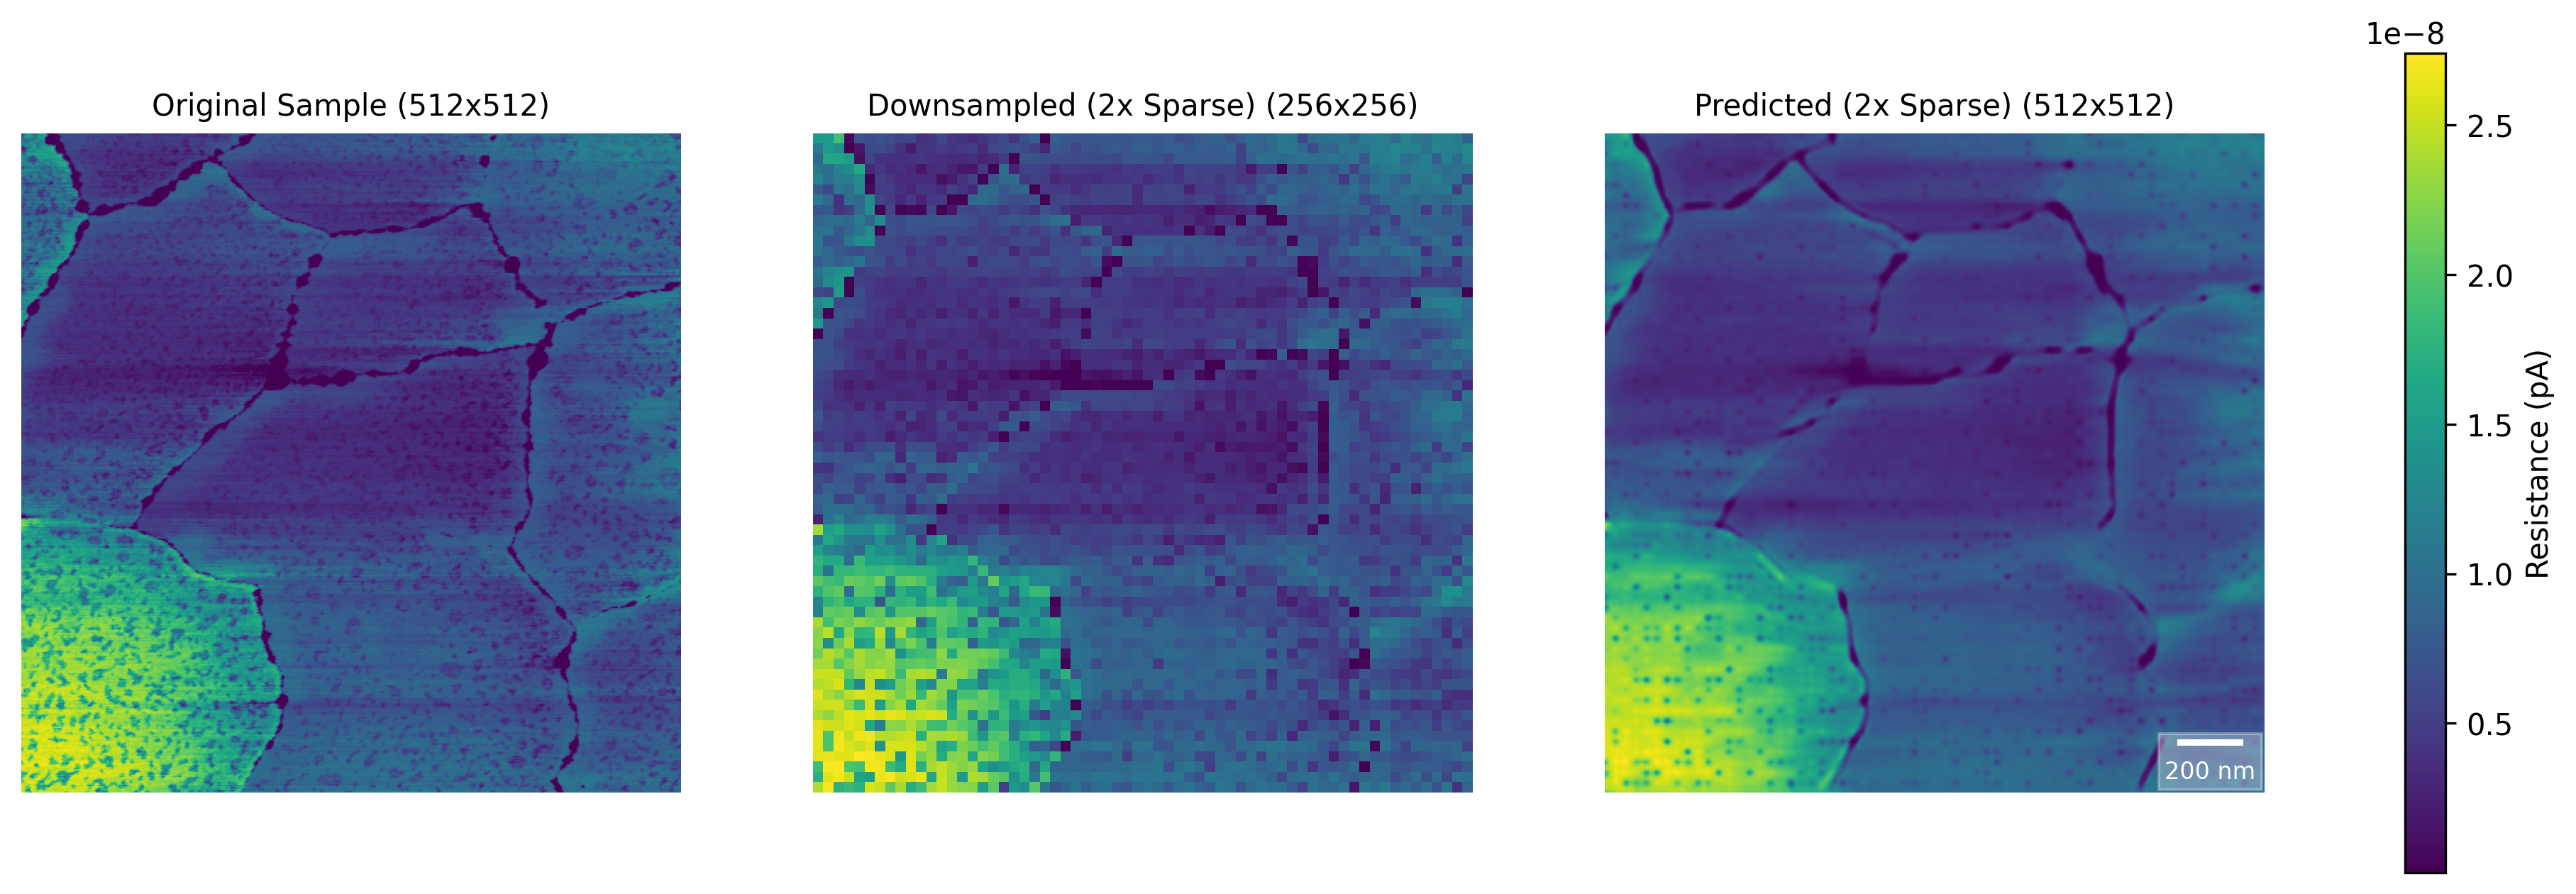

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import torch

# Example restructured code

# 1. Retrieve the data
item = dataset.get_item_p_y_bar_y_sparse(0)
original_data = item["y_og"]
downsampled_data = original_data[::8, ::8]  # 256 x 256

# 2. Prepare the model input
model_in = torch.Tensor(downsampled_data).cuda().float().unsqueeze(0)  # (1, 256, 256)

# 3. Forward pass through the model (no grad)
with torch.no_grad():
    pred_torch = model(model_in)  # shape: (1, 512, 512)

# Convert to NumPy and do normalization
pred = pred_torch.squeeze(0).cpu().numpy()
pred_min, pred_max = pred.min(), pred.max()
range_diff = pred_max - pred_min

# Check to avoid division by zero
# if range_diff > 1e-12:  
#     pred = (pred - pred_min) / range_diff
# else:
#     pred = np.zeros_like(pred)

# Scale by dataset-specific max, if that is the correct calibration
pred *= dataset.current_maps_max

# 4. Create the figure and axes
fig, axes = plt.subplots(
    nrows=1, ncols=3,
    figsize=(17, 5),  # You may tweak this
    dpi=300
)

# 5. Plot original data
# Decide on a color map if needed, e.g. cmap='viridis' or 'gray'
im0 = axes[0].imshow(original_data, cmap='viridis')
axes[0].set_title("Original Sample (512x512)", fontsize=10)
axes[0].axis("off")

# 6. Plot downsampled data
im1 = axes[1].imshow(downsampled_data, cmap='viridis')
axes[1].set_title("Downsampled (2x Sparse) (256x256)", fontsize=10)
axes[1].axis("off")

# 7. Plot predicted data
im2 = axes[2].imshow(pred, cmap='viridis')
axes[2].set_title("Predicted (2x Sparse) (512x512)", fontsize=10)
axes[2].axis("off")

# 8. Add a colorbar
# Here, we create one colorbar that covers all three subplots.
# If you'd prefer separate colorbars, you can do so individually.
cbar = fig.colorbar(
    im2, 
    ax=axes.ravel().tolist(),
)
cbar.set_label("Resistance (pA)", fontsize=10)

# 9. Add scale bar (on the predicted image, for example)
pixel_size_um = 2.0 / 512  # 2 micrometers across 512 pixels
scalebar = ScaleBar(
    pixel_size_um,        # scaling factor
    "um",                 # units
    location="lower right",
    box_alpha=0.3,
    color="white",
    font_properties={"size": 8}
)
axes[2].add_artist(scalebar)

# plt.tight_layout()

plt.show();

In [8]:
def undo_min_max_scaling(x):
    return x * (dataset.current_maps_max - dataset.current_maps_min) + dataset.current_maps_min

y = torch.Tensor(undo_min_max_scaling(original_data)).cpu()
y_hat = torch.Tensor(undo_min_max_scaling(pred_torch)).cpu().squeeze(0)

torch.nn.functional.l1_loss(y, y_hat), (torch.nn.functional.l1_loss(y, y_hat) / y.mean()) * 100

(tensor(1.1095e-09), tensor(14.2242))